In [1]:
from pathlib import Path
from typing import Tuple

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# np.set_printoptions(precision=4)

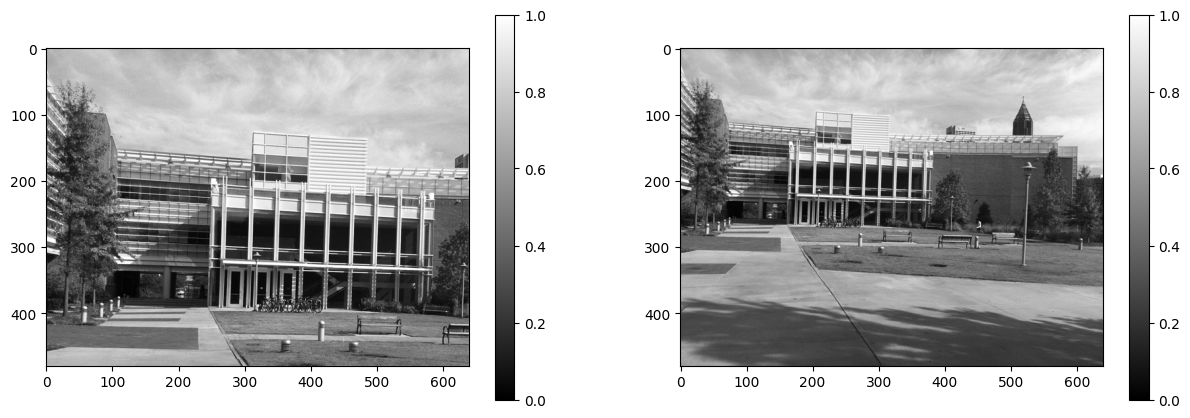

In [2]:
input_dir = Path('input')

img_trans_a = cv.imread(str(input_dir / 'transA.jpg'), cv.IMREAD_UNCHANGED)
img_sim_a = cv.imread(str(input_dir / 'simA.jpg'), cv.IMREAD_UNCHANGED)

img_trans_a = img_trans_a.astype(np.float32) / 255
img_sim_a = img_sim_a.astype(np.float32) / 255

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(img_trans_a, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(img_sim_a, cmap="gray")
plt.colorbar()
plt.show()

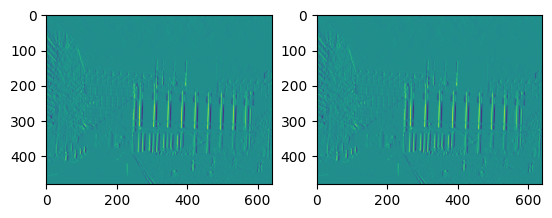

[[ 0.          4.85857129 18.71399581 ... -0.86820781 -2.91705787
   0.        ]
 [ 0.          5.99619985 17.50715017 ... -1.48369879 -4.20649588
   0.        ]
 [ 0.          6.64982557 14.0869689  ... -2.53938854 -6.25139415
   0.        ]
 ...
 [ 0.         -4.06055331 -6.00914955 ... 11.0529837  16.27135009
   0.        ]
 [ 0.         -1.25554383 -2.73229659 ... 14.07367721 15.99880591
   0.        ]
 [ 0.          0.26622891 -1.43604934 ... 13.58536541 13.6937052
   0.        ]]
[[ 0.          4.85984802 18.71566772 ... -0.86769104 -2.91824341
   0.        ]
 [ 0.          5.99601746 17.50946045 ... -1.48441315 -4.2061615
   0.        ]
 [ 0.          6.64970398 14.08927917 ... -2.54276276 -6.24893188
   0.        ]
 ...
 [ 0.         -4.05830383 -6.01741791 ... 11.05236053 16.27212524
   0.        ]
 [ 0.         -1.25289917 -2.74120331 ... 14.07176971 15.99781036
   0.        ]
 [ 0.          0.26847839 -1.44355774 ... 13.58345032 13.69239807
   0.        ]]


In [18]:
def compute_gradients(img, kernel_size=3, sigma=3):
    img = img.copy().astype(np.float32)
    img = cv.GaussianBlur(img, (kernel_size, kernel_size), sigma)
    sobelx = cv.Sobel(img,cv.CV_64F,1,0,ksize=kernel_size)
    sobely = cv.Sobel(img,cv.CV_64F,0,1,ksize=kernel_size)
    
    return sobelx, sobely

sx, sy = compute_gradients(img_trans_a)
sx1, sy1 = compute_gradients(img_trans_a.astype(np.float32) + np.full_like(img_trans_a, 100).astype(np.float32))

plt.subplot(121)
plt.imshow(sx * 255)

plt.subplot(122)
plt.imshow(sx1 * 255)
